In [1]:
# This information helps with debugging and getting support :)
import sys, platform
import pandas as pd
import bifacial_radiance as br
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("bifacial_radiance version ", br.__version__)

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
bifacial_radiance version  0.5.1.dev12+ga93ff8171.d20251201


In [2]:
import os
from pathlib import Path

testfolder = 'TEMP'
if not os.path.exists(testfolder):
    os.makedirs(testfolder)

print ("Your simulation will be stored in %s" % testfolder)


Your simulation will be stored in TEMP


In [3]:
import bifacial_radiance
import numpy as np

rad_obj = bifacial_radiance.RadianceObj('Si', str(testfolder)) 


path = TEMP


<a id='step1'></a>

## 1. Making Collectors for each number panel and xgap case

In [4]:
rad_obj.setGround(0.2)  # This prints available materials.

Loading albedo, 1 value(s), 0.200 avg
1 nonzero albedo values.


In [5]:
epwfile = rad_obj.getEPW(lat = 42.98, lon = -81.24)

Getting weather file: CAN_ON_London.716230_CWEC.epw
 ... OK!


In [6]:
startdate = '04_01'     
enddate = '10_31'
metdata = rad_obj.readWeatherFile(epwfile, coerce_year=2025, starttime=startdate, endtime=enddate)


8760 line in WeatherFile. Assuming this is a standard hourly WeatherFile for the year for purposes of saving Gencumulativesky temporary weather files in EPW folder.
Coercing year to 2025
Filtering dates
Saving file EPWs\metdata_temp.csv, # points: 8760
Calculating Sun position for Metdata that is right-labeled  with a delta of -30 mins. i.e. 12 is 11:30 sunpos


In [7]:
metdata

<class 'bifacial_radiance.main.MetObj'>.metadata:
{'latitude': 43.03, 'longitude': -81.15, 'elevation': 278.0, 'timezone': -5.0, 'city': 'London', 'label': 'right'}
<class 'bifacial_radiance.main.MetObj'>.tmydata:
 <class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2898 entries, 2025-04-01 07:00:00-05:00 to 2025-10-31 17:00:00-05:00
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ghi         2898 non-null   int64  
 1   dhi         2898 non-null   int64  
 2   dni         2898 non-null   int64  
 3   albedo      2898 non-null   float64
 4   dewpoint    2898 non-null   float64
 5   pressure    2898 non-null   int64  
 6   temp_air    2898 non-null   float64
 7   wind_speed  2898 non-null   float64
dtypes: float64(4), int64(4)

In [8]:
#rad_obj.genCumSky() # entire year.
metdata.datetime[1035] # Selected for having GHI = 982 , clear sky day. # ('2025-06-13 13:00:00-0500', tz='UTC-05:00')
timeindex = metdata.datetime.index(pd.to_datetime('2025-06-13 13:00:00 -5'))
rad_obj.gendaylit(timeindex)  # Noon, June 17th (timepoint # 4020)

'skies\\sky2_43.03_-81.15_2025-06-13_1300.rad'

## CdTe
Order:  G B R

ORDER: # G60 G70 G80  B60 B70 B80 R40 R50 R70 R80



In [9]:
#Module width: 1.2m; spacing 0.15
G60_x =  -(1.2*4 + 4*0.15)
G70_x = -(1.2*3 + 3*0.15)
G80_x = -(1.2*2 + 2*0.15)
B60_x = -(1.2*1 + 1*0.15)
B70_x = 0
B80_x = 1.2*1 + 1*0.15
R40_x = 1.2*2 + 2*0.15
R50_x = 1.2*3 + 3*0.15
R70_x = 1.2*4 + 4*0.15
R80_x = 1.2*5 + 5*0.15

In [10]:
description = 'G60'
materialname = 'G60'
RTrans = 0.6
GTrans = 0.6 
BTrans = 0.6
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'G70'
materialname = 'G70'
RTrans = 0.7
GTrans = 0.7 
BTrans = 0.7
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'G80'
materialname = 'G80'
RTrans = 0.8
GTrans = 0.8 
BTrans = 0.8
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'B60'
materialname = 'B60'
RTrans = 0.6
GTrans = 0.6 
BTrans = 0.6
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'B70'
materialname = 'B70'
RTrans = 0.7
GTrans = 0.7 
BTrans = 0.7
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'B80'
materialname = 'B80'
RTrans = 0.8
GTrans = 0.8 
BTrans = 0.8
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'R40'
materialname = 'R40'
RTrans = 0.4
GTrans = 0.4 
BTrans = 0.4
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'R50'
materialname = 'R50'
RTrans = 0.5
GTrans = 0.5 
BTrans = 0.5
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)


description = 'R70'
materialname = 'R70'
RTrans = 0.7
GTrans = 0.7 
BTrans = 0.7
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'R80'
materialname = 'R80'
RTrans = 0.8
GTrans = 0.8 
BTrans = 0.8
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)


Material exists, overwriting...

Added material G60 to file ground.rad
Material exists, overwriting...

Added material G70 to file ground.rad
Material exists, overwriting...

Added material G80 to file ground.rad
Material exists, overwriting...

Added material B60 to file ground.rad
Material exists, overwriting...

Added material B70 to file ground.rad
Material exists, overwriting...

Added material B80 to file ground.rad
Material exists, overwriting...

Added material R40 to file ground.rad
Material exists, overwriting...

Added material R50 to file ground.rad
Material exists, overwriting...

Added material R70 to file ground.rad
Material exists, overwriting...

Added material R80 to file ground.rad


In [11]:
'''
description = 'CdTe 60percent transmission'
materialname = 'cdte_60trans'
RTrans = 0.6
GTrans = 0.6 
BTrans = 0.6
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'CdTe 60percent transmission'
materialname = 'cdte_60trans'
RTrans = 0.6
GTrans = 0.6 
BTrans = 0.6
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'CdTe 70percent transmission'
materialname = 'cdte_70trans'
RTrans = 0.7
GTrans = 0.7 
BTrans = 0.7
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

description = 'CdTe 80percent transmission'
materialname = 'cdte_80trans'
RTrans = 0.8
GTrans = 0.8 
BTrans = 0.8
materialtype = 'glass'
rad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)

cdTe60 = rad_obj.makeModule(name='cdTe60',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='cdte_60trans')
cdTe70 = rad_obj.makeModule(name='cdTe70',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='cdte_70trans')
cdTe80 = rad_obj.makeModule(name='cdTe80r',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='cdte_80trans')

sceneDict1 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 3, 'nRows': 1, 'originx': -4.05, 'originy': 0, 'appendRadfile':True} 
sceneDict2 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 3, 'nRows': 1, 'originx': 0, 'originy': 0, 'appendRadfile':True} 
sceneDict3 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 4, 'nRows': 1, 'originx': 4.05, 'originy': 0, 'appendRadfile':True}


sceneObj1 = rad_obj.makeScene(cdTe60, sceneDict1)  
sceneObj2 = rad_obj.makeScene(cdTe70, sceneDict2, append=True)  
sceneObj3 = rad_obj.makeScene(cdTe80, sceneDict3, append=True)  

'''

"\ndescription = 'CdTe 60percent transmission'\nmaterialname = 'cdte_60trans'\nRTrans = 0.6\nGTrans = 0.6 \nBTrans = 0.6\nmaterialtype = 'glass'\nrad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)\n\ndescription = 'CdTe 60percent transmission'\nmaterialname = 'cdte_60trans'\nRTrans = 0.6\nGTrans = 0.6 \nBTrans = 0.6\nmaterialtype = 'glass'\nrad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)\n\ndescription = 'CdTe 70percent transmission'\nmaterialname = 'cdte_70trans'\nRTrans = 0.7\nGTrans = 0.7 \nBTrans = 0.7\nmaterialtype = 'glass'\nrad_obj.addMaterial(material=materialname, Rrefl=RTrans, Grefl=GTrans, Brefl=BTrans, materialtype='glass', comment=description)\n\ndescription = 'CdTe 80percent transmission'\nmaterialname = 'cdte_80trans'\nRTrans = 0.8\nGTrans = 0.8 \nBTrans = 0.8\nmaterialtype = 'glass'\nrad_obj.addMaterial(material=mat

In [12]:
#G60 G70 G80  B60 B70 B80 R40 R50 R70 R80
G60 = rad_obj.makeModule(name='G60',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='G60')
G70 = rad_obj.makeModule(name='G70',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='G70')
G80 = rad_obj.makeModule(name='G80',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='G80')

B60 = rad_obj.makeModule(name='B60',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='B60')
B70 = rad_obj.makeModule(name='B70',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='B70')
B80 = rad_obj.makeModule(name='B80',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='B80')

R40 = rad_obj.makeModule(name='R40',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='R40')
R50 = rad_obj.makeModule(name='R50',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='R50')
R70 = rad_obj.makeModule(name='R70',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='R70')
R80 = rad_obj.makeModule(name='R80',x=1.2,y=0.6, numpanels=2, xgap = 0.15, modulematerial='R80')


Module Name: G60
Module G60 updated in module.json
Pre-existing .rad file objects\G60.rad will be overwritten


Module Name: G70
Module G70 updated in module.json
Pre-existing .rad file objects\G70.rad will be overwritten


Module Name: G80
Module G80 updated in module.json
Pre-existing .rad file objects\G80.rad will be overwritten


Module Name: B60
Module B60 updated in module.json
Pre-existing .rad file objects\B60.rad will be overwritten


Module Name: B70
Module B70 updated in module.json
Pre-existing .rad file objects\B70.rad will be overwritten


Module Name: B80
Module B80 updated in module.json
Pre-existing .rad file objects\B80.rad will be overwritten


Module Name: R40
Module R40 updated in module.json
Pre-existing .rad file objects\R40.rad will be overwritten


Module Name: R50
Module R50 updated in module.json
Pre-existing .rad file objects\R50.rad will be overwritten


Module Name: R70
Module R70 updated in module.json
Pre-existing .rad file objects\R70.rad will be overw

In [13]:
#G60 G70 G80  B60 B70 B80 R40 R50 R70 R80
sceneDict1 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': G60_x, 'originy': 0, 'appendRadfile':True} 
sceneDict2 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': G70_x, 'originy': 0, 'appendRadfile':True} 
sceneDict3 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': G80_x, 'originy': 0, 'appendRadfile':True}
sceneDict4 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': B60_x, 'originy': 0, 'appendRadfile':True}
sceneDict5 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': B70_x, 'originy': 0, 'appendRadfile':True}
sceneDict6 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': B80_x, 'originy': 0, 'appendRadfile':True}
sceneDict7 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': R40_x, 'originy': 0, 'appendRadfile':True}
sceneDict8 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': R50_x, 'originy': 0, 'appendRadfile':True}
sceneDict9 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': R70_x, 'originy': 0, 'appendRadfile':True}
sceneDict10 = {'tilt':34,'pitch':5.69,'clearance_height':2.0,'azimuth':180, 'nMods': 1, 'nRows': 1, 'originx': R80_x, 'originy': 0, 'appendRadfile':True}

sceneObj1 = rad_obj.makeScene(G60, sceneDict1)  
sceneObj2 = rad_obj.makeScene(G70, sceneDict2, append=True)  
sceneObj3 = rad_obj.makeScene(G80, sceneDict3, append=True)  
sceneObj4 = rad_obj.makeScene(B60, sceneDict4, append=True)  
sceneObj5 = rad_obj.makeScene(B70, sceneDict5, append=True)  
sceneObj6 = rad_obj.makeScene(B80, sceneDict6, append=True)  
sceneObj7 = rad_obj.makeScene(R40, sceneDict7, append=True)  
sceneObj8 = rad_obj.makeScene(R50, sceneDict8, append=True)  
sceneObj9 = rad_obj.makeScene(R70, sceneDict9, append=True)  
sceneObj10 = rad_obj.makeScene(R80, sceneDict10, append=True)  


Additional scene Scene1 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene2 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene3 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene4 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene5 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene6 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene7 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene8 created! See list of names with RadianceObj.scenes and sceneNames
Additional scene Scene9 created! See list of names with RadianceObj.scenes and sceneNames


In [14]:
octfile = rad_obj.makeOct(rad_obj.getfilelist()) 

Created Si.oct


In [15]:
rad_obj.getfilelist()

['materials\\ground.rad',
 'skies\\sky2_43.03_-81.15_2025-06-13_1300.rad',
 'objects\\G60_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-5.3999999999999995,0.rad',
 'objects\\G70_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-4.05,0.rad',
 'objects\\G80_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-2.6999999999999997,0.rad',
 'objects\\B60_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-1.3499999999999999,0.rad',
 'objects\\B70_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin0,0.rad',
 'objects\\B80_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin1.3499999999999999,0.rad',
 'objects\\R40_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin2.6999999999999997,0.rad',
 'objects\\R50_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin4.05,0.rad',
 'objects\\R70_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin5.3999999999999995,0.rad',
 'objects\\R80_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin6.75,0.rad']

In [16]:
#!objview materials\ground.rad objects\\Si_44_C_0.70_rtr_5.69_tilt_34_3modsx1rows_origin3.827,0.rad


In [33]:
#!rvu -vf views\front.vp -e .02 -pe 0.3 -vp 0 -13.5 18.5 -vd 0 0.7 -0.7 Si.oct

In [18]:
analysis = bifacial_radiance.AnalysisObj()

In [19]:
groundscan = analysis.groundAnalysis(sceneObj2, modWanted=1, rowWanted=1, sensorsground=2, sensorsgroundx=2)

In [20]:
groundscan

{'xstart': np.float16(-4.05),
 'ystart': np.float16(0.0),
 'zstart': np.float16(0.05),
 'xinc': np.float16(0.0),
 'yinc': np.float16(-5.69),
 'zinc': np.float16(0.0),
 'sx_xinc': np.float64(0.45),
 'sx_yinc': np.float64(5.5109105961630896e-17),
 'sx_zinc': 0.0,
 'Nx': 2,
 'Ny': 2,
 'Nz': 1,
 'orient': '0 0 -1'}

In [21]:
# Faster
#groundscan['xstart'] = -6.4
#groundscan['ystart'] = -1.2
#groundscan['Nx'] = 12
#groundscan['Ny'] = 26
#groundscan['yinc'] = 0.5
#groundscan['sx_xinc'] = 0.5
#groundscan['sx_yinc'] = 0.0

In [22]:
# SUPER RESOLUTION 5 cm
groundscan['xstart'] = -7
groundscan['ystart'] = -1
groundscan['Nx'] = 307
groundscan['Ny'] = 120
groundscan['yinc'] = 0.05
groundscan['sx_xinc'] = 0.05
groundscan['sx_yinc'] = 0.0

In [23]:
#irr__CdTE_test_noon_5cm_Row1_Module2

In [24]:
analysis.analysis(octfile, '_SingleHour_', groundscan)  # compare the back vs front irradiance

Linescan in process: _SingleHour__Row1_Module1_Front
Saved: results\irr__SingleHour__Row1_Module1.csv


{'Wm2': array([978.9644, 978.9617, 978.959 , ..., 977.7335, 977.7321, 977.7305]),
 'x': array([-7. , -7. , -7. , ...,  8.3,  8.3,  8.3]),
 'y': array([-1.  , -0.95, -0.9 , ...,  4.85,  4.9 ,  4.95]),
 'z': array([0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05]),
 'r': array([978.9644, 978.9617, 978.959 , ..., 977.7335, 977.7321, 977.7305]),
 'g': array([978.9644, 978.9617, 978.959 , ..., 977.7335, 977.7321, 977.7305]),
 'b': array([978.9644, 978.9617, 978.959 , ..., 977.7335, 977.7321, 977.7305]),
 'mattype': array(['groundplane', 'groundplane', 'groundplane', ..., 'groundplane',
        'groundplane', 'groundplane'], dtype='<U32'),
 'title': '_SingleHour__Row1_Module1_Front'}

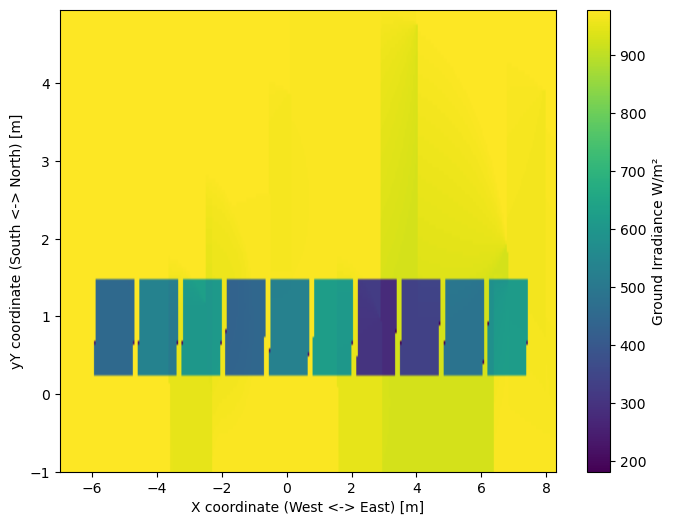

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr__SingleHour__Row1_Module1.csv')   # columns: x, y, z, mattype, Wm2Front

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get unique coordinate axes ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape Wm2Front into 2D array ---
# IMPORTANT: df is sorted so reshape works correctly
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
plt.imshow(Z.T, origin='lower',
           extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           aspect='auto')

plt.colorbar(label='Ground Irradiance W/m²')
plt.xlabel('X coordinate (West <-> East) [m]')
plt.ylabel('yY coordinate (South <-> North) [m]')
#plt.title('Ground Irradiance')
plt.show()

In [26]:
## Seasonal
rad_obj.genCumSky() # entire year.
octfile = rad_obj.makeOct(rad_obj.getfilelist()) 
rad_obj.getfilelist()

Loaded  EPWs\metdata_temp.csv
message: Error!  Solar altitude is -6 < -6 degrees and Idh = 34 > 10 W/m^2 on day 91 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -8 < -6 degrees and Idh = 11 > 10 W/m^2 on day 132 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -7 < -6 degrees and Idh = 14 > 10 W/m^2 on day 136 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -7 < -6 degrees and Idh = 11 > 10 W/m^2 on day 137 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 12 > 10 W/m^2 on day 138 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 14 > 10 W/m^2 on day 140 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 21 > 10 W/m^2 on day 215 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 18 > 10 W/m^2 on day 215 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -7 < -6 degrees and Idh = 15 > 1

['materials\\ground.rad',
 'skies\\cumulative.rad',
 'objects\\G60_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-5.3999999999999995,0.rad',
 'objects\\G70_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-4.05,0.rad',
 'objects\\G80_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-2.6999999999999997,0.rad',
 'objects\\B60_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin-1.3499999999999999,0.rad',
 'objects\\B70_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin0,0.rad',
 'objects\\B80_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin1.3499999999999999,0.rad',
 'objects\\R40_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin2.6999999999999997,0.rad',
 'objects\\R50_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin4.05,0.rad',
 'objects\\R70_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin5.3999999999999995,0.rad',
 'objects\\R80_C_2.00_rtr_5.69_tilt_34_1modsx1rows_origin6.75,0.rad']

In [27]:
analysis.analysis(octfile, '__Full_Year_5cm', groundscan)  # compare the back vs front irradiance

Linescan in process: __Full_Year_5cm_Row1_Module1_Front
Saved: results\irr___Full_Year_5cm_Row1_Module1.csv


{'Wm2': array([1053364. , 1053352. , 1053340. , ...,  998631.1,  998621. ,
         998611. ]),
 'x': array([-7. , -7. , -7. , ...,  8.3,  8.3,  8.3]),
 'y': array([-1.  , -0.95, -0.9 , ...,  4.85,  4.9 ,  4.95]),
 'z': array([0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05]),
 'r': array([1053364. , 1053352. , 1053340. , ...,  998631.1,  998621. ,
         998611. ]),
 'g': array([1053364. , 1053352. , 1053340. , ...,  998631.1,  998621. ,
         998611. ]),
 'b': array([1053364. , 1053352. , 1053340. , ...,  998631.1,  998621. ,
         998611. ]),
 'mattype': array(['groundplane', 'groundplane', 'groundplane', ..., 'groundplane',
        'groundplane', 'groundplane'], dtype='<U32'),
 'title': '__Full_Year_5cm_Row1_Module1_Front'}

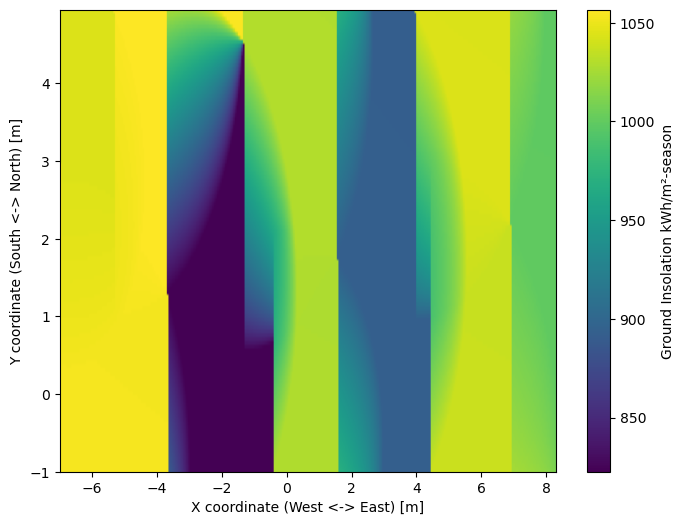

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr___Full_Year_5cm_Row1_Module1.csv')

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get unique coordinate axes ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape Wm2Front into 2D array ---
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Convert Wh/m² → kWh/m² ---
Z = Z / 1000.0     # <<< THIS LINE FIXES THE 1e6 SCALE ISSUE

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
plt.imshow(Z.T, origin='lower',
           extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           aspect='auto')

plt.colorbar(label='Ground Insolation kWh/m²-season')
plt.xlabel('X coordinate (West <-> East) [m]')
plt.ylabel('Y coordinate (South <-> North) [m]')
plt.show()


In [34]:
print("Max Wh/m²-season:", df['Wm2Front'].max())
print("Max kWh/m²-season:", df['Wm2Front'].max() / 1000)


Max Wh/m²-season: 1052733.0
Max kWh/m²-season: 1052.733


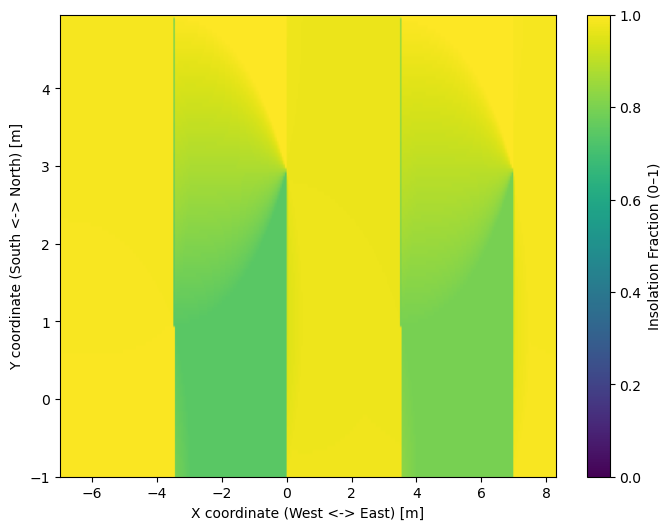

Max value in dataset: 1052733.0


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
#df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr__CdTE_test_Season_5cm_Row1_Module2.csv')
#df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr___Full_Year_5cm_Row1_Module1.csv')

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get unique coordinate axes ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape Wm2Front into 2D array ---
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Normalize by max to get Insolation Fraction ---
Zmax = Z.max()
Z = Z / Zmax       # values now between 0 and 1

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
plt.imshow(Z.T, origin='lower',
           extent=[xs.min(), xs.max(), ys.min(), ys.max()],
           aspect='auto',
           vmin=0, vmax=1)   # enforce 0–1 scale

plt.colorbar(label='Insolation Fraction (0–1)')
plt.xlabel('X coordinate (West <-> East) [m]')
plt.ylabel('Y coordinate (South <-> North) [m]')
plt.show()

print("Max value in dataset:", Zmax)


In [36]:
target_x = -4
target_y = 0.2

# compute distance to each row
df['dist'] = np.sqrt((df['x'] - target_x)**2 + (df['y'] - target_y)**2)

# pick closest row
closest = df.loc[df['dist'].idxmin()]

print("Closest grid point:", closest[['x', 'y']].to_dict())
print("Wm2Front value:", closest['Wm2Front'])
print("Normalized value:", closest['Wm2Front'] / df['Wm2Front'].max())


Closest grid point: {'x': -4.0, 'y': 0.2}
Wm2Front value: 1047841.0
Normalized value: 0.9953530477338508


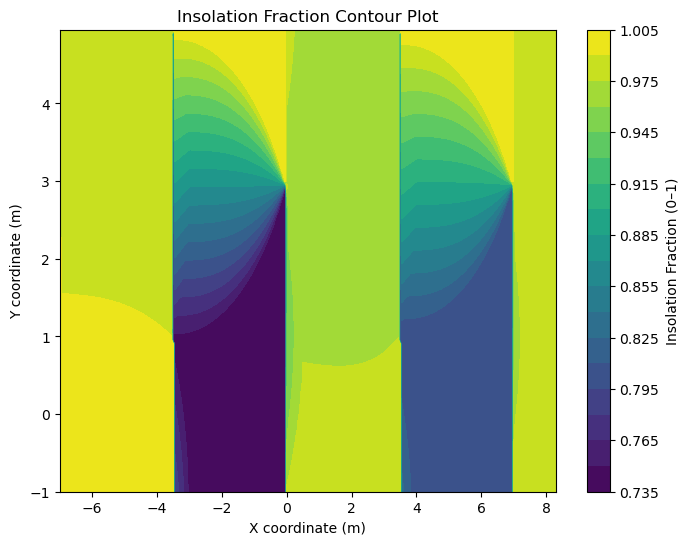

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load CSV ---
#df = pd.read_csv(r'C:\Users\sayala\Documents\GitHub\bifacial_radiance\docs\Studies\TEMP\results\irr__CdTE_test_Season_5cm_Row1_Module2.csv')

# --- Sort so y increases first, then x ---
df = df.sort_values(['x', 'y'])

# --- Get coordinate grids ---
xs = np.sort(df['x'].unique())
ys = np.sort(df['y'].unique())

# --- Reshape data ---
Z = df['Wm2Front'].values.reshape(len(xs), len(ys))

# --- Normalize for Insolation Fraction ---
Zmax = Z.max()
Znorm = Z / Zmax

# --- Create meshgrid for contour plot ---
X, Y = np.meshgrid(xs, ys, indexing='ij')

# --- Plot contour ---
plt.figure(figsize=(8,6))
contour = plt.contourf(X, Y, Znorm, levels=20, cmap='viridis')

plt.colorbar(contour, label='Insolation Fraction (0–1)')
plt.xlabel('X coordinate (m)')
plt.ylabel('Y coordinate (m)')
plt.title('Insolation Fraction Contour Plot')

plt.show()
